In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/nearest_neighbour.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/nearest_neighbour.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/nearest_neighbour.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/nearest_neighbour.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/nearest_neighbour.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)



condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': "#a71394",
    '23129': "#3318e3",
    '33300': "#cfee1e",
}

In [2]:
""" 
PER-FILE AGGREGATION STATISTICS

One number per recording, so the recording is the unit of replication (n = 10).
Far more power than the roseplot, which conditions on proximity -- the very
thing that differs between genotypes.
"""

DISTANCE = 'head_distance'          # or 'closest_node_distance'
CONTROL = 'wiii8'
compare_conditions = ['anosmic', '9047', '23129', '33300']

d = df.dropna(subset=[DISTANCE]).copy()

per_file = (
    d.groupby(['condition', 'filename'], as_index=False)
     .agg(
         frac_within_2mm=(DISTANCE, lambda s: (s < 2).mean()),
         frac_within_5mm=(DISTANCE, lambda s: (s < 5).mean()),
         mean_nn_distance=(DISTANCE, 'mean'),
         median_nn_distance=(DISTANCE, 'median'),
     )
)

per_file['condition'] = pd.Categorical(per_file['condition'], condition_order, ordered=True)
per_file = per_file.sort_values(['condition', 'filename']).reset_index(drop=True)

METRICS = [
    ('frac_within_2mm',    'Fraction of time within 2mm'),
    ('frac_within_5mm',    'Fraction of time within 5mm'),
    ('mean_nn_distance',   'Mean NN distance (mm)'),
    ('median_nn_distance', 'Median NN distance (mm)'),
]

print('distance metric:', DISTANCE)
print(per_file.groupby('condition', observed=True).size().rename('n_files'), '\n')
print(per_file.groupby('condition', observed=True)[[m for m, _ in METRICS]].mean().round(4))

distance metric: head_distance
condition
wiii8      10
anosmic    10
9047       10
23129      10
33300      10
Name: n_files, dtype: int64 

           frac_within_2mm  frac_within_5mm  mean_nn_distance  \
condition                                                       
wiii8               0.0701           0.1560           22.2903   
anosmic             0.0243           0.0841           21.0993   
9047                0.0522           0.1255           20.7941   
23129               0.0403           0.1158           21.2021   
33300               0.0438           0.1207           24.5897   

           median_nn_distance  
condition                      
wiii8                 19.1184  
anosmic               18.9178  
9047                  18.3616  
23129                 17.7135  
33300                 20.5537  


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_25234/3425907707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_25234/3425907707.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_25234/3425907707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_25234/3425907707.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

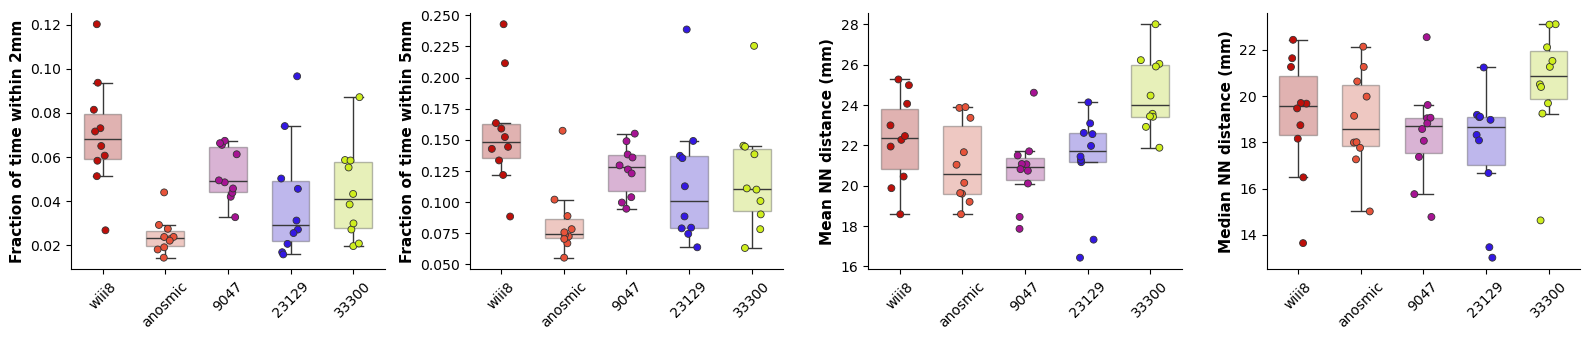

In [3]:
""" DISTRIBUTION OF EACH PER-FILE STATISTIC (each point = one recording) """

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 3.5))

for ax, (metric, label) in zip(axes, METRICS):
    pal = [condition_colors[c] for c in condition_order]

    sns.boxplot(
        data=per_file, x='condition', y=metric, order=condition_order,
        palette=pal, showfliers=False, width=0.6,
        boxprops=dict(alpha=0.35), ax=ax,
    )
    sns.stripplot(
        data=per_file, x='condition', y=metric, order=condition_order,
        palette=pal, size=5, edgecolor='0.2', linewidth=0.6, jitter=0.15, ax=ax,
    )

    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

In [4]:
""" 
BOOTSTRAP EACH MUTANT AGAINST wiii8

Resample recordings with replacement within each condition, take the difference
in means, and read the CI + p off the bootstrap distribution. Same logic as the
roseplot but on a single per-file number, so it is fast and 10,000 resamples is
cheap. FDR-corrected across the four mutants within each metric.

NOTE: with 10,000 resamples the smallest non-zero p_boot is 2e-4; a printed 0.0
means "< 2e-4", not exactly zero.
"""

from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

RESAMPLES = 10000


def bootstrap_difference(test_vals, ctrl_vals, resamples=RESAMPLES, seed=0):
    rng = np.random.default_rng(seed)
    obs = test_vals.mean() - ctrl_vals.mean()
    boot_t = rng.choice(test_vals, size=(resamples, len(test_vals)), replace=True).mean(axis=1)
    boot_c = rng.choice(ctrl_vals, size=(resamples, len(ctrl_vals)), replace=True).mean(axis=1)
    boot = boot_t - boot_c
    lo, hi = np.quantile(boot, [0.025, 0.975])
    p = 2 * min((boot <= 0).mean(), (boot >= 0).mean())
    return obs, lo, hi, p


rows = []
for metric, label in METRICS:
    ctrl = per_file.loc[per_file['condition'] == CONTROL, metric].to_numpy()
    for cond in compare_conditions:
        test = per_file.loc[per_file['condition'] == cond, metric].to_numpy()
        obs, lo, hi, p = bootstrap_difference(test, ctrl)
        _, p_mwu = mannwhitneyu(test, ctrl, alternative='two-sided')
        rows.append({
            'metric': metric,
            'condition': cond,
            'wiii8': ctrl.mean(),
            'mutant': test.mean(),
            'difference': obs,
            'ci_low': lo,
            'ci_high': hi,
            'p_boot': p,
            'p_mannwhitney': p_mwu,
        })

results = pd.DataFrame(rows)

# FDR across the four mutants, separately for each metric
results['p_fdr'] = np.nan
for metric, g in results.groupby('metric'):
    results.loc[g.index, 'p_fdr'] = multipletests(g['p_boot'], method='fdr_bh')[1]

results['sig'] = np.select(
    [results['p_fdr'] < 0.001, results['p_fdr'] < 0.01, results['p_fdr'] < 0.05],
    ['***', '**', '*'],
    default='ns',
)

pd.set_option('display.width', 250)
print(results.round(4).to_string(index=False))

            metric condition   wiii8  mutant  difference  ci_low  ci_high  p_boot  p_mannwhitney  p_fdr sig
   frac_within_2mm   anosmic  0.0701  0.0243     -0.0458 -0.0615  -0.0304  0.0000         0.0004 0.0000 ***
   frac_within_2mm      9047  0.0701  0.0522     -0.0180 -0.0347  -0.0021  0.0258         0.0640 0.0258   *
   frac_within_2mm     23129  0.0701  0.0403     -0.0299 -0.0512  -0.0079  0.0088         0.0257 0.0117   *
   frac_within_2mm     33300  0.0701  0.0438     -0.0264 -0.0453  -0.0068  0.0076         0.0257 0.0117   *
   frac_within_5mm   anosmic  0.1560  0.0841     -0.0719 -0.1025  -0.0416  0.0000         0.0017 0.0000 ***
   frac_within_5mm      9047  0.1560  0.1255     -0.0305 -0.0595  -0.0033  0.0268         0.0757 0.0536  ns
   frac_within_5mm     23129  0.1560  0.1158     -0.0402 -0.0793   0.0016  0.0576         0.0376 0.0684  ns
   frac_within_5mm     33300  0.1560  0.1207     -0.0353 -0.0715   0.0028  0.0684         0.0757 0.0684  ns
  mean_nn_distance   anosmic

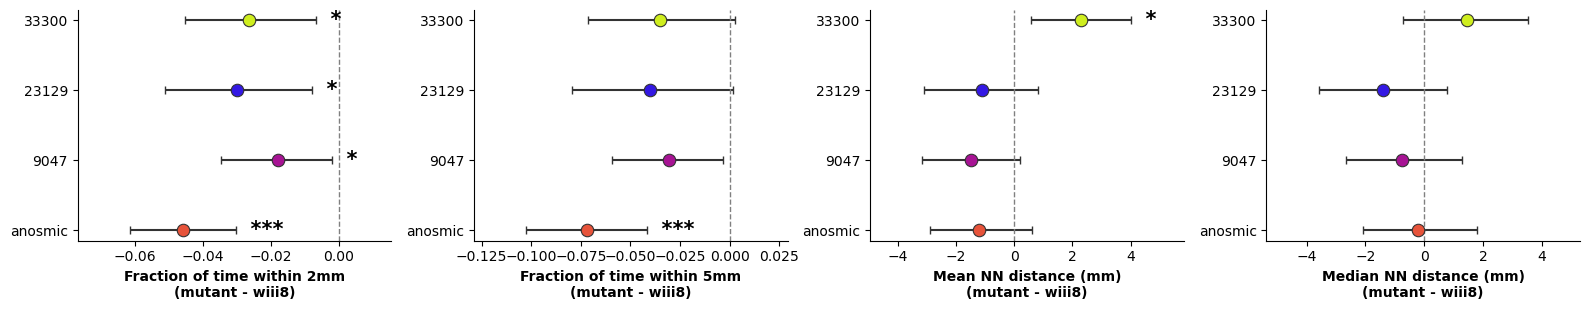

In [5]:
""" EFFECT SIZE PER MUTANT (mutant - wiii8), 95% bootstrap CI, FDR-corrected """

fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 3.2))

for ax, (metric, label) in zip(axes, METRICS):
    sub = results[results['metric'] == metric].set_index('condition').loc[compare_conditions]
    y = np.arange(len(sub))

    xerr = np.vstack([
        np.clip(sub['difference'] - sub['ci_low'], 0, None),
        np.clip(sub['ci_high'] - sub['difference'], 0, None),
    ])

    ax.errorbar(sub['difference'], y, xerr=xerr, fmt='none',
                ecolor='0.2', capsize=3, linewidth=1.5)

    for i, cond in enumerate(compare_conditions):
        ax.plot(sub.loc[cond, 'difference'], i, 'o',
                color=condition_colors[cond], markersize=9,
                markeredgecolor='0.2', markeredgewidth=0.8, zorder=3)

    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(compare_conditions)
    ax.set_xlabel(f'{label}\n(mutant - wiii8)', fontsize=10, fontweight='bold')

    for i, s in enumerate(sub['sig']):
        if s != 'ns':
            ax.text(sub['ci_high'].iloc[i], i, '  ' + s,
                    va='center', ha='left', fontsize=15, fontweight='bold')

    ax.margins(x=0.25)

sns.despine()
plt.tight_layout()
plt.show()